# 15. Threshold Tuning for Fraud Detection

This notebook tunes the Random Forest fraud-probability threshold selected for the credit card fraud detection workflow. Notebook `14_model_evaluation.ipynb` showed that Random Forest is the strongest candidate model because it provides better practical fraud-detection performance than Logistic Regression, especially in PR-AUC, F1-score, top-risk ranking, and alert-volume control.


## Threshold Tuning Objective

A classification threshold is the probability cutoff used to convert a model's fraud probability into an operational fraud signal. The `0.50` threshold is a technical default used by many classifiers. In fraud detection, it is usually not the best business threshold because fraud is rare and missing fraud can be more costly than reviewing extra alerts. Therefore, `0.50` is shown only as a **reference baseline**, not as the recommended final threshold.

The business goal is to catch more fraud cases while keeping false positives manageable. The main trade-off is between **recall** and **precision**: higher recall catches more fraud, while higher precision keeps alerts cleaner. False negatives represent missed fraud, and false positives represent legitimate transactions that may require review or cause customer friction.


## Methodology Note: Avoid Tuning on Final Test Set

In this notebook, the threshold is selected using saved holdout/test predictions for project learning and demonstration purposes. In a stricter production ML workflow, the threshold should be tuned on a validation set or out-of-fold cross-validation predictions. The final test set should be used only once for final unbiased evaluation.

For this academic project this is acceptable for demonstration, but for production this should be improved.

| Dataset Split | Purpose |
|---|---|
| Train set | Train the model |
| Validation set / CV predictions | Tune threshold |
| Final test set | Final unbiased evaluation |


## Load Libraries and Project Paths

The notebook reuses the saved holdout predictions and trained Random Forest artifact created by notebook `13_model_training.ipynb` and evaluated in notebook `14_model_evaluation.ipynb`.


In [12]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

try:
    from IPython.display import Markdown, display
except ImportError:
    Markdown = str
    display = print

sys.path.append(str(Path("..").resolve()))
from src.config import PROJECT_ROOT

NOTEBOOK_NAME = "15_threshold_tuning"
MODEL_NAME = "Random Forest"
TARGET_COLUMN = "Class"

TRAINING_NOTEBOOK_NAME = "13_model_training"
TRAINING_TABLES_DIR = PROJECT_ROOT / "reports" / "tables" / TRAINING_NOTEBOOK_NAME
TRAINING_ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / TRAINING_NOTEBOOK_NAME

PREDICTIONS_FILE = TRAINING_TABLES_DIR / "baseline_test_predictions.csv"
RANDOM_FOREST_ARTIFACT_FILE = TRAINING_ARTIFACTS_DIR / "baseline_random_forest.joblib"
SPLIT_IDS_FILE = TRAINING_ARTIFACTS_DIR / "train_test_split_ids.json"
SELECTED_DATA_FILE = PROJECT_ROOT / "data" / "processed" / "creditcard_selected_features.csv"

ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
REPORTS_TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
SELECTED_THRESHOLD_FILE = ARTIFACTS_DIR / "selected_threshold.json"
THRESHOLD_EVALUATION_FILE = REPORTS_TABLES_DIR / "threshold_evaluation.csv"

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_TABLES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.6f}")
sns.set_theme(style="whitegrid")

print(f"Project root: {PROJECT_ROOT}")
print(f"Prediction file: {PREDICTIONS_FILE}")
print(f"Selected threshold artifact: {SELECTED_THRESHOLD_FILE}")


Project root: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection
Prediction file: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/13_model_training/baseline_test_predictions.csv
Selected threshold artifact: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/selected_threshold.json


## Load Random Forest Holdout Probabilities

The preferred path is to reuse the saved holdout probabilities from the earlier modeling workflow. If the prediction file is not available, the fallback path loads the saved Random Forest pipeline and the saved test transaction IDs, then regenerates holdout probabilities from the selected-feature dataset.


In [13]:
def require_file(path: Path, artifact_name: str) -> Path:
    if not path.exists():
        raise FileNotFoundError(f"Missing {artifact_name}: {path}")
    return path


def load_saved_holdout_predictions(prediction_file: Path) -> pd.DataFrame | None:
    if not prediction_file.exists():
        return None

    predictions = pd.read_csv(prediction_file)
    required_columns = {"y_true", "random_forest_probability"}
    missing_columns = sorted(required_columns - set(predictions.columns))
    if missing_columns:
        raise ValueError(f"Saved prediction file is missing required columns: {missing_columns}")

    return predictions.copy()


def regenerate_random_forest_predictions() -> pd.DataFrame:
    require_file(RANDOM_FOREST_ARTIFACT_FILE, "Random Forest model artifact")
    require_file(SPLIT_IDS_FILE, "train/test split ID artifact")
    require_file(SELECTED_DATA_FILE, "selected feature dataset")

    rf_artifact = joblib.load(RANDOM_FOREST_ARTIFACT_FILE)
    random_forest_model = rf_artifact["model"]
    selected_features = rf_artifact["selected_features"]

    selected_df = pd.read_csv(SELECTED_DATA_FILE)
    missing_columns = sorted(set(selected_features + [TARGET_COLUMN]) - set(selected_df.columns))
    if missing_columns:
        raise ValueError(f"Selected data is missing required columns: {missing_columns}")

    model_df = selected_df.loc[:, selected_features + [TARGET_COLUMN]].copy()
    model_df["transaction_id"] = np.arange(len(model_df))

    split_ids = json.loads(SPLIT_IDS_FILE.read_text(encoding="utf-8"))
    test_transaction_ids = set(split_ids["test_transaction_ids"])
    holdout_df = model_df.loc[model_df["transaction_id"].isin(test_transaction_ids)].sort_values("transaction_id")

    X_test = holdout_df[selected_features]
    y_test = holdout_df[TARGET_COLUMN].astype(int)
    y_proba_rf = random_forest_model.predict_proba(X_test)[:, 1]

    return pd.DataFrame(
        {
            "transaction_id": holdout_df["transaction_id"].to_numpy(),
            "y_true": y_test.to_numpy(),
            "random_forest_probability": y_proba_rf,
        }
    )


holdout_predictions = load_saved_holdout_predictions(PREDICTIONS_FILE)
if holdout_predictions is None:
    print("Saved predictions were not found. Regenerating Random Forest holdout probabilities from saved artifacts.")
    holdout_predictions = regenerate_random_forest_predictions()
else:
    print("Loaded saved holdout predictions from notebook 13 outputs.")

holdout_predictions["y_true"] = holdout_predictions["y_true"].astype(int)
y_true = holdout_predictions["y_true"]
y_proba_rf = holdout_predictions["random_forest_probability"]

holdout_summary = pd.DataFrame(
    [
        {"Metric": "Holdout rows", "Value": int(len(holdout_predictions))},
        {"Metric": "Actual fraud cases", "Value": int(y_true.sum())},
        {"Metric": "Actual normal cases", "Value": int((y_true == 0).sum())},
        {"Metric": "Fraud rate", "Value": float(y_true.mean())},
        {"Metric": "Minimum RF probability", "Value": float(y_proba_rf.min())},
        {"Metric": "Maximum RF probability", "Value": float(y_proba_rf.max())},
    ]
)

display(holdout_summary)


Loaded saved holdout predictions from notebook 13 outputs.


,Metric,Value
0,Holdout rows,56746.000000
1,Actual fraud cases,95.000000
2,Actual normal cases,56651.000000
3,Fraud rate,0.001674
4,Minimum RF probability,0.000000
5,Maximum RF probability,1.000000


### Holdout Data Interpretation

This table confirms the evaluation population used for threshold tuning. The holdout set is highly imbalanced, so a threshold must be chosen with fraud-specific metrics rather than accuracy alone. The Random Forest probabilities are the risk scores that will be converted into review decisions at different thresholds.


## Threshold Evaluation Table

This table shows how model performance changes as the fraud probability threshold changes.

A finer threshold grid is used because small threshold changes can meaningfully affect false positives and false negatives in imbalanced fraud detection. Each row represents one threshold from `0.001` to `0.999`. Lower thresholds usually catch more fraud cases but create more false positives. Higher thresholds usually reduce false alarms but can miss more fraud. This table is the main evidence for choosing a business review threshold.


In [14]:
def evaluate_thresholds(y_true: pd.Series, y_proba: pd.Series, thresholds: np.ndarray) -> pd.DataFrame:
    rows = []
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        rows.append(
            {
                "threshold": float(threshold),
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0),
                "f1_score": f1_score(y_true, y_pred, zero_division=0),
                "accuracy": accuracy_score(y_true, y_pred),
                "true_positives": int(tp),
                "false_positives": int(fp),
                "true_negatives": int(tn),
                "false_negatives": int(fn),
                "frauds_caught": int(tp),
                "frauds_missed": int(fn),
                "total_predicted_frauds": int(y_pred.sum()),
            }
        )
    return pd.DataFrame(rows).sort_values("threshold").reset_index(drop=True)


thresholds = np.round(np.arange(0.001, 1.000, 0.001), 3)
threshold_evaluation = evaluate_thresholds(y_true, y_proba_rf, thresholds)
threshold_evaluation.to_csv(THRESHOLD_EVALUATION_FILE, index=False)

display(threshold_evaluation)
print(f"Saved threshold evaluation table to: {THRESHOLD_EVALUATION_FILE}")


,threshold,precision,recall,f1_score,accuracy,true_positives,false_positives,true_negatives,false_negatives,frauds_caught,frauds_missed,total_predicted_frauds
0,0.001000,0.081489,0.852632,0.148760,0.983664,81,913,55738,14,81,14,994
1,0.002000,0.081489,0.852632,0.148760,0.983664,81,913,55738,14,81,14,994
2,0.003000,0.081489,0.852632,0.148760,0.983664,81,913,55738,14,81,14,994
3,0.004000,0.081489,0.852632,0.148760,0.983664,81,913,55738,14,81,14,994
4,0.005000,0.081489,0.852632,0.148760,0.983664,81,913,55738,14,81,14,994
...,...,...,...,...,...,...,...,...,...,...,...,...
994,0.995000,1.000000,0.094737,0.173077,0.998484,9,0,56651,86,9,86,9
995,0.996000,1.000000,0.094737,0.173077,0.998484,9,0,56651,86,9,86,9
996,0.997000,1.000000,0.094737,0.173077,0.998484,9,0,56651,86,9,86,9
997,0.998000,1.000000,0.094737,0.173077,0.998484,9,0,56651,86,9,86,9


Saved threshold evaluation table to: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/reports/tables/threshold_evaluation.csv


### Threshold Evaluation Interpretation

The table shows the full precision-recall trade-off. At very low thresholds, recall is high because more fraud cases are flagged, but false positives increase sharply. At higher thresholds, precision improves because alerts become cleaner, but missed fraud increases. The selected review threshold should improve fraud capture compared with the `0.50` reference cutoff while keeping false positives reasonable for manual review.


## Threshold Metrics Plot

This chart shows how model behavior changes as the classification threshold changes. Lower thresholds usually increase recall but reduce precision. Higher thresholds usually increase precision but reduce recall. F1-score is useful, but it is not the only decision criterion because fraud detection must reflect the business cost of false negatives and false positives.


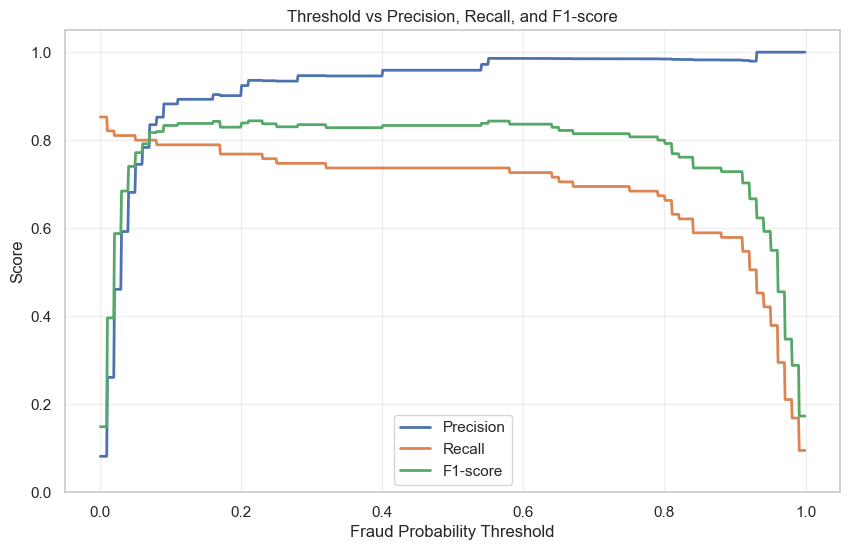

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["precision"], label="Precision", linewidth=2)
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["recall"], label="Recall", linewidth=2)
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["f1_score"], label="F1-score", linewidth=2)
ax.set_title("Threshold vs Precision, Recall, and F1-score")
ax.set_xlabel("Fraud Probability Threshold")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


### Precision, Recall, and F1 Interpretation

This graph shows how the main classification metrics move as the threshold changes. Recall is strongest at low thresholds because the model flags more transactions as risky. Precision improves as the threshold becomes stricter because fewer normal transactions are flagged. Although the selected threshold may have a slightly lower F1-score than the technical `0.50` threshold, it better matches the business goal because it improves fraud recall. In fraud detection, the best threshold is not always the one with the highest F1-score; it should reflect the business cost of false negatives and false positives.


## Error Trade-Off Plot

This chart helps compare business consequences, especially false positives and false negatives. In fraud detection, false negatives are important because they represent fraud cases missed by the model. Lower thresholds usually reduce false negatives but increase false positives.


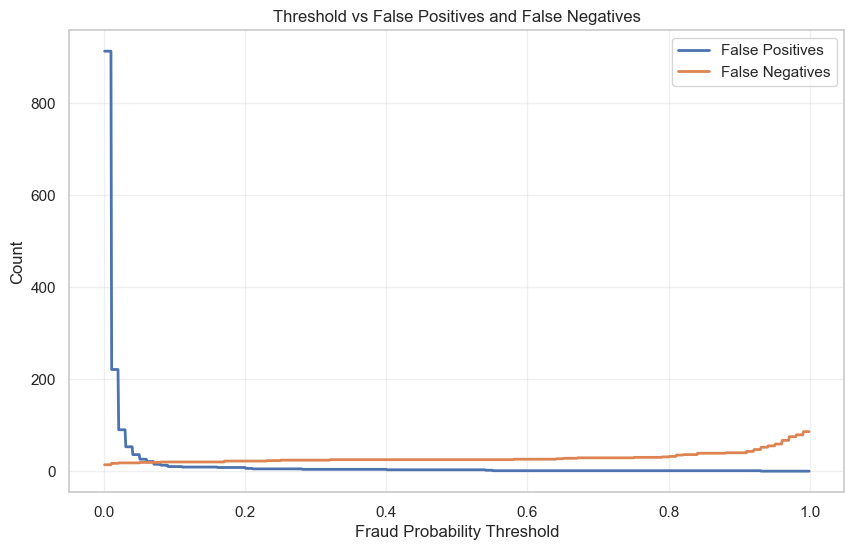

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["false_positives"], label="False Positives", linewidth=2)
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["false_negatives"], label="False Negatives", linewidth=2)
ax.set_title("Threshold vs False Positives and False Negatives")
ax.set_xlabel("Fraud Probability Threshold")
ax.set_ylabel("Count")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


### Error Trade-Off Interpretation

This graph shows the operational cost of changing the threshold. A lower threshold catches more fraud but increases false alarms. A higher threshold reduces false positives but increases missed frauds. The selected threshold is chosen because it meets the business recall target while keeping precision acceptable.


## Fraud Capture Plot

The next graph focuses only on actual fraud cases: how many are caught and how many are missed at each threshold. This directly supports the business goal of reducing missed fraud.


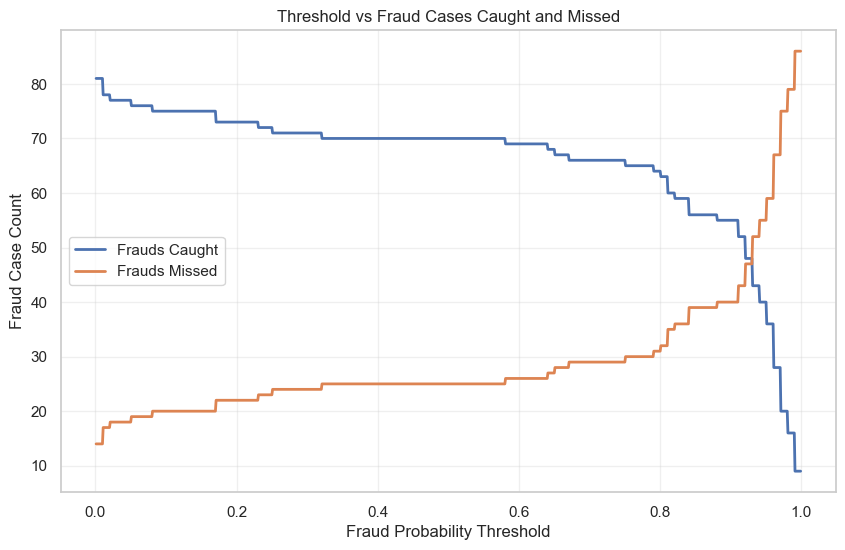

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["frauds_caught"], label="Frauds Caught", linewidth=2)
ax.plot(threshold_evaluation["threshold"], threshold_evaluation["frauds_missed"], label="Frauds Missed", linewidth=2)
ax.set_title("Threshold vs Fraud Cases Caught and Missed")
ax.set_xlabel("Fraud Probability Threshold")
ax.set_ylabel("Fraud Case Count")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


### Fraud Capture Interpretation

This graph translates threshold tuning into fraud-detection impact. Fraud cases caught are true positives, and fraud cases missed are false negatives. A useful review threshold should reduce missed fraud compared with the `0.50` reference cutoff, but it should not create an unmanageable number of false alerts.


## Candidate Threshold Selection

This section selects multiple candidate thresholds:

- best threshold by maximum F1-score
- best threshold with recall at least `0.80`, if available
- best threshold with recall at least `0.90`, if available
- a practical balance threshold between precision and recall

The selected review threshold is chosen from these computed candidates. It should be treated as the review threshold, not as an automatic blocking threshold.


In [18]:
def pick_best_f1_row(threshold_df: pd.DataFrame) -> pd.Series:
    return threshold_df.sort_values(["f1_score", "recall", "precision"], ascending=False).iloc[0]


def pick_recall_floor_row(threshold_df: pd.DataFrame, recall_floor: float) -> pd.Series | None:
    eligible = threshold_df.loc[threshold_df["recall"] >= recall_floor].copy()
    if eligible.empty:
        return None
    return eligible.sort_values(["precision", "f1_score", "threshold"], ascending=[False, False, False]).iloc[0]


def make_candidate_row(candidate_name: str, row: pd.Series | None, reason: str) -> dict:
    if row is None:
        return {
            "candidate": candidate_name,
            "threshold": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1_score": np.nan,
            "false_positives": np.nan,
            "false_negatives": np.nan,
            "frauds_caught": np.nan,
            "frauds_missed": np.nan,
            "total_predicted_frauds": np.nan,
            "reason": reason,
        }
    return {
        "candidate": candidate_name,
        "threshold": float(row["threshold"]),
        "precision": float(row["precision"]),
        "recall": float(row["recall"]),
        "f1_score": float(row["f1_score"]),
        "false_positives": int(row["false_positives"]),
        "false_negatives": int(row["false_negatives"]),
        "frauds_caught": int(row["frauds_caught"]),
        "frauds_missed": int(row["frauds_missed"]),
        "total_predicted_frauds": int(row["total_predicted_frauds"]),
        "reason": reason,
    }


best_f1_row = pick_best_f1_row(threshold_evaluation)
recall_80_row = pick_recall_floor_row(threshold_evaluation, 0.80)
recall_90_row = pick_recall_floor_row(threshold_evaluation, 0.90)

if recall_80_row is not None and recall_80_row["precision"] >= 0.75:
    practical_balance_row = recall_80_row
    practical_reason = "Best precision among thresholds with recall >= 0.80 and acceptable alert quality."
else:
    practical_balance_row = best_f1_row
    practical_reason = "Best F1-score because no recall >= 0.80 threshold met the alert-quality requirement."

candidate_thresholds = pd.DataFrame(
    [
        make_candidate_row("Best F1-score", best_f1_row, "Maximizes the balance between precision and recall."),
        make_candidate_row("Recall >= 0.80", recall_80_row, "Prioritizes catching at least 80% of fraud cases if possible."),
        make_candidate_row("Recall >= 0.90", recall_90_row, "Prioritizes catching at least 90% of fraud cases if possible."),
        make_candidate_row("Practical review threshold", practical_balance_row, practical_reason),
    ]
)

display(candidate_thresholds)


,candidate,threshold,precision,recall,f1_score,false_positives,false_negatives,frauds_caught,frauds_missed,total_predicted_frauds,reason
0,Best F1-score,0.211000,0.935897,0.768421,0.843931,5.000000,22.000000,73.000000,22.000000,78.000000,Maximizes the balance between precision and re...
1,Recall >= 0.80,0.080000,0.835165,0.800000,0.817204,15.000000,19.000000,76.000000,19.000000,91.000000,Prioritizes catching at least 80% of fraud cas...
2,Recall >= 0.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Prioritizes catching at least 90% of fraud cas...
3,Practical review threshold,0.080000,0.835165,0.800000,0.817204,15.000000,19.000000,76.000000,19.000000,91.000000,Best precision among thresholds with recall >=...


### Candidate Threshold Interpretation

The candidate table shows that the best F1 threshold is not automatically the best business threshold. Fraud detection often accepts a few more false positives if doing so catches more fraud. The practical review threshold is designed to prefer recall of at least `0.80` when precision remains strong enough to keep the review queue reasonable. If recall `0.90` is not available, the notebook keeps that row blank to avoid forcing an unrealistic operating point.


## Reference Comparison: Technical Default 0.50 vs Business-Selected Review Threshold

The `0.50` threshold is a technical reference cutoff, not the recommended business threshold. This section compares it against the selected review threshold so the trade-off is visible.


In [19]:
def select_review_threshold(candidate_thresholds: pd.DataFrame) -> tuple[pd.Series, str]:
    practical = candidate_thresholds.loc[candidate_thresholds["candidate"] == "Practical review threshold"].iloc[0]
    best_f1 = candidate_thresholds.loc[candidate_thresholds["candidate"] == "Best F1-score"].iloc[0]

    if pd.notna(practical["threshold"]):
        reason = (
            "Selected as the review threshold to catch at least 80% of fraud cases while keeping precision high enough "
            "for a manageable alert queue."
        )
        return practical, reason

    reason = "Selected as the review threshold because it provides the strongest F1-score when no higher-recall threshold is practical."
    return best_f1, reason


selected_threshold_row, selected_threshold_reason = select_review_threshold(candidate_thresholds)
selected_threshold = float(selected_threshold_row["threshold"])
review_threshold = selected_threshold
reference_threshold = 0.50

reference_row = threshold_evaluation.loc[np.isclose(threshold_evaluation["threshold"], reference_threshold)].iloc[0]
selected_row = threshold_evaluation.loc[np.isclose(threshold_evaluation["threshold"], review_threshold)].iloc[0]

comparison_table = pd.DataFrame(
    [
        {"threshold_type": "Technical Default 0.50 — Reference Only", **reference_row.to_dict()},
        {"threshold_type": "Business-Selected Review Threshold", **selected_row.to_dict()},
    ]
)

extra_frauds_caught = int(selected_row["frauds_caught"] - reference_row["frauds_caught"])
false_negatives_reduced = int(reference_row["false_negatives"] - selected_row["false_negatives"])
false_positives_increased = int(selected_row["false_positives"] - reference_row["false_positives"])
precision_difference = float(selected_row["precision"] - reference_row["precision"])
recall_difference = float(selected_row["recall"] - reference_row["recall"])
f1_difference = float(selected_row["f1_score"] - reference_row["f1_score"])

display(comparison_table)
print(f"Review threshold selected: {review_threshold:.3f}")
print(selected_threshold_reason)


,threshold_type,threshold,precision,recall,f1_score,accuracy,true_positives,false_positives,true_negatives,false_negatives,frauds_caught,frauds_missed,total_predicted_frauds
0,Technical Default 0.50 — Reference Only,0.500000,0.958904,0.736842,0.833333,0.999507,70.000000,3.000000,56648.000000,25.000000,70.000000,25.000000,73.000000
1,Business-Selected Review Threshold,0.080000,0.835165,0.800000,0.817204,0.999401,76.000000,15.000000,56636.000000,19.000000,76.000000,19.000000,91.000000


Review threshold selected: 0.080
Selected as the review threshold to catch at least 80% of fraud cases while keeping precision high enough for a manageable alert queue.


In [20]:
display(Markdown(f"""
### Reference Comparison Interpretation

The selected threshold `{review_threshold:.3f}` is preferred because it catches more fraud cases and reaches the target recall level. The technical default `0.50` is shown only as a reference baseline. It is not selected because it misses more fraud cases.

Compared with the `0.50` reference cutoff, the selected review threshold catches **{extra_frauds_caught:+d}** more fraud cases, reduces false negatives by **{false_negatives_reduced:d}**, and increases false positives by **{false_positives_increased:d}**. This is acceptable because fraud detection prioritizes reducing missed fraud while keeping review volume manageable.

Although the selected threshold has an F1-score difference of **{f1_difference:+.4f}** versus the technical `0.50` cutoff, it better matches the business goal because recall improves by **{recall_difference:+.4f}**. F1-score is useful, but it is not the only decision criterion. Missing fraud can be more costly than sending extra transactions to review.
"""))



### Reference Comparison Interpretation

The selected threshold `0.080` is preferred because it catches more fraud cases and reaches the target recall level. The technical default `0.50` is shown only as a reference baseline. It is not selected because it misses more fraud cases.

Compared with the `0.50` reference cutoff, the selected review threshold catches **+6** more fraud cases, reduces false negatives by **6**, and increases false positives by **12**. This is acceptable because fraud detection prioritizes reducing missed fraud while keeping review volume manageable.

Although the selected threshold has an F1-score difference of **-0.0161** versus the technical `0.50` cutoff, it better matches the business goal because recall improves by **+0.0632**. F1-score is useful, but it is not the only decision criterion. Missing fraud can be more costly than sending extra transactions to review.


## Review Threshold Meaning

The selected threshold should be treated as the **review threshold**. Transactions with fraud probability greater than or equal to this threshold should not automatically be blocked; they should enter the `REVIEW` or higher-risk decision flow.


## Confusion Matrix Comparison

This chart helps compare business consequences, especially false positives and false negatives. In fraud detection, false negatives are important because they represent fraud cases missed by the model. The `0.50` reference cutoff is shown only for comparison against the selected review threshold.


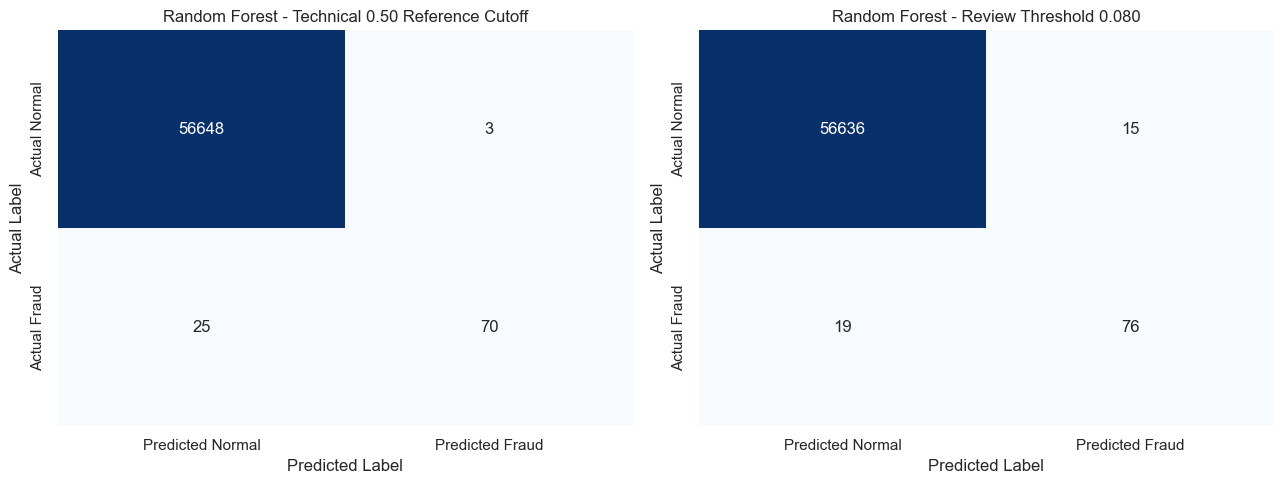

In [21]:
def plot_confusion_matrix_for_threshold(y_true: pd.Series, y_proba: pd.Series, threshold: float, ax, title: str):
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Predicted Normal", "Predicted Fraud"],
        yticklabels=["Actual Normal", "Actual Fraud"],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("Actual Label")


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_confusion_matrix_for_threshold(
    y_true,
    y_proba_rf,
    reference_threshold,
    axes[0],
    "Random Forest - Technical 0.50 Reference Cutoff",
)
plot_confusion_matrix_for_threshold(
    y_true,
    y_proba_rf,
    review_threshold,
    axes[1],
    f"Random Forest - Review Threshold {review_threshold:.3f}",
)
fig.tight_layout()
plt.show()


### Confusion Matrix Interpretation

The technical `0.50` reference cutoff is stricter and produces fewer false positives, but it misses more fraud. The selected review threshold lowers the cutoff so more real fraud cases are caught. The accepted business trade-off is more review alerts in exchange for fewer missed fraud cases.


## Final Business Interpretation Table

The table below translates the selected review threshold into business language.


In [22]:
selected_precision = float(selected_row["precision"])
selected_recall = float(selected_row["recall"])
selected_f1_score = float(selected_row["f1_score"])
selected_false_positives = int(selected_row["false_positives"])
selected_false_negatives = int(selected_row["false_negatives"])
selected_frauds_caught = int(selected_row["frauds_caught"])
selected_total_alerts = int(selected_row["total_predicted_frauds"])

reference_frauds_caught = int(reference_row["frauds_caught"])
reference_false_positives = int(reference_row["false_positives"])
reference_false_negatives = int(reference_row["false_negatives"])

business_interpretation = pd.DataFrame(
    [
        {
            "Metric": "Review Threshold",
            "Value": f"{review_threshold:.3f}",
            "Meaning": "Transactions above this probability enter the REVIEW or higher-risk decision flow.",
        },
        {
            "Metric": "Recall",
            "Value": f"{selected_recall:.2%}",
            "Meaning": "Percentage of actual fraud cases caught.",
        },
        {
            "Metric": "Precision",
            "Value": f"{selected_precision:.2%}",
            "Meaning": "Percentage of predicted frauds that are truly fraud.",
        },
        {
            "Metric": "False Positives",
            "Value": selected_false_positives,
            "Meaning": "Legitimate transactions incorrectly flagged for the risky flow.",
        },
        {
            "Metric": "False Negatives",
            "Value": selected_false_negatives,
            "Meaning": "Fraud transactions missed by the model.",
        },
        {
            "Metric": "Decision Impact",
            "Value": (
                f"Catches {extra_frauds_caught:+d} more fraud cases than the 0.50 reference cutoff "
                f"with {false_positives_increased:+d} additional false positives."
            ),
            "Meaning": "Business trade-off accepted for stronger fraud recall.",
        },
    ]
)

display(business_interpretation)


,Metric,Value,Meaning
0,Review Threshold,0.080,Transactions above this probability enter the ...
1,Recall,80.00%,Percentage of actual fraud cases caught.
2,Precision,83.52%,Percentage of predicted frauds that are truly ...
3,False Positives,15,Legitimate transactions incorrectly flagged fo...
4,False Negatives,19,Fraud transactions missed by the model.
5,Decision Impact,Catches +6 more fraud cases than the 0.50 refe...,Business trade-off accepted for stronger fraud...


### Business Interpretation

The review threshold treats more transactions as risky than the technical `0.50` reference cutoff, but it catches more fraud cases. In fraud detection, this can be acceptable because missed fraud is usually more costly than reviewing a small number of additional alerts. This threshold is therefore a strong input for the next decision-logic notebook.


## Save Selected Review Threshold Artifact

The selected review threshold is saved for downstream notebooks and API integration work. The artifact labels the threshold role clearly so it is not confused with an automatic blocking threshold.


In [23]:
block_threshold_example = 0.50
selected_threshold_payload = {
    "model_name": MODEL_NAME,
    "selected_threshold": selected_threshold,
    "review_threshold": review_threshold,
    "threshold_role": "review_threshold",
    "note": "Selected threshold is intended for REVIEW decision boundary, not automatic blocking.",
    "selection_reason": selected_threshold_reason,
    "precision": selected_precision,
    "recall": selected_recall,
    "f1_score": selected_f1_score,
    "false_positives": selected_false_positives,
    "false_negatives": selected_false_negatives,
    "frauds_caught": selected_frauds_caught,
    "total_predicted_frauds": selected_total_alerts,
    "reference_threshold": reference_threshold,
    "reference_threshold_role": "technical_default_reference_only",
    "reference_frauds_caught": reference_frauds_caught,
    "reference_false_positives": reference_false_positives,
    "reference_false_negatives": reference_false_negatives,
    "extra_frauds_caught_vs_reference": extra_frauds_caught,
    "false_negatives_reduced_vs_reference": false_negatives_reduced,
    "false_positives_increased_vs_reference": false_positives_increased,
    "precision_difference_vs_reference": precision_difference,
    "recall_difference_vs_reference": recall_difference,
    "f1_score_difference_vs_reference": f1_difference,
    "block_threshold_example": block_threshold_example,
    "block_threshold_status": "example_only_not_final",
}

SELECTED_THRESHOLD_FILE.write_text(json.dumps(selected_threshold_payload, indent=2), encoding="utf-8")
print(f"Saved selected threshold artifact to: {SELECTED_THRESHOLD_FILE}")
print(json.dumps(selected_threshold_payload, indent=2))


Saved selected threshold artifact to: /Users/mohammadmubashir/VCode/Credit-Card-Fraud-Detection/artifacts/selected_threshold.json
{
  "model_name": "Random Forest",
  "selected_threshold": 0.08,
  "review_threshold": 0.08,
  "threshold_role": "review_threshold",
  "note": "Selected threshold is intended for REVIEW decision boundary, not automatic blocking.",
  "selection_reason": "Selected as the review threshold to catch at least 80% of fraud cases while keeping precision high enough for a manageable alert queue.",
  "precision": 0.8351648351648352,
  "recall": 0.8,
  "f1_score": 0.8172043010752689,
  "false_positives": 15,
  "false_negatives": 19,
  "frauds_caught": 76,
  "total_predicted_frauds": 91,
  "reference_threshold": 0.5,
  "reference_threshold_role": "technical_default_reference_only",
  "reference_frauds_caught": 70,
  "reference_false_positives": 3,
  "reference_false_negatives": 25,
  "extra_frauds_caught_vs_reference": 6,
  "false_negatives_reduced_vs_reference": 6,
  "

### Saved Artifact Interpretation

The JSON artifact records the selected model, selected review threshold, threshold role, selection reason, and core metrics. It also stores the technical `0.50` reference cutoff metrics for comparison. If a block threshold appears in the artifact, it is explicitly labeled as an example only and not final.


## Final Conclusion

Threshold tuning was needed because the technical default threshold `0.50` is not designed for highly imbalanced fraud detection and is not recommended as the final fraud threshold. Random Forest already ranked fraud cases well, but the operating threshold controls how many transactions enter the risky decision flow.

The selected review threshold is preferred because it improves fraud recall and catches more fraud cases than the `0.50` reference cutoff. This threshold catches more fraud but creates more false positives. The trade-off is acceptable for fraud detection because missed fraud is costly, and the resulting review volume remains manageable.

In the next notebook, this threshold should be used in a `BLOCK` / `REVIEW` / `APPROVE` decision system. A separate higher block threshold should be selected or justified before any automatic blocking is used.


## Connection to Next Notebook: Decision Logic

In the next notebook, this threshold will be used as the review threshold, not necessarily the block threshold. A separate higher block threshold should be selected or justified for automatic blocking.

```python
review_threshold = 0.08
block_threshold = 0.50  # Example only; should be validated separately

if fraud_probability >= block_threshold:
    decision = "BLOCK"
elif fraud_probability >= review_threshold:
    decision = "REVIEW"
else:
    decision = "APPROVE"
```

Using two thresholds is more realistic than using one threshold because low-risk transactions can be approved, medium-risk transactions can be reviewed, and very high-risk transactions can be blocked.

Next Step: `16_decision_logic.ipynb`
